In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
# Geometry objectors
from hypo.lenspy import simple_Lens 
from hypo.surface import BiconicSurface,ConicSurface
from hypo.coordinate import coord_sys
# source objector
from hypo.Feedpy import GaussiBeam

# output objector
from hypo.field_storage import Spherical_grd, plane_grd, save_grd 
from hypo.coxvec import Ludwig_Cox_vector as CO
from hypo.vecops import Vector, dot

outputdatafolder = 'Data/biconic4_HDPE/'

In [2]:
'''1. Define coordinate system'''
coord_ref = coord_sys()
coord_feed = coord_sys(ref_coord = coord_ref)
coord_Lens1 = coord_sys(origin = [0,0,100], ref_coord= coord_ref)
coord_Lens2 = coord_sys(origin = [0,0,383], ref_coord= coord_ref)
coord_out = coord_sys(origin = [0,0,383 + 180], ref_coord =coord_ref)

In [3]:
'''2. Define lens two surfaces'''
r1_x =  67.6 # mm
r1_y = 52
k1_x = -2.31
k1_y = -2.31
Lens1_face1 = BiconicSurface(r1_x, r1_y, conic_const_x=k1_x, conic_const_y=k1_y)
r1_2 = np.inf 
Lens1_face2 = ConicSurface(r1_2)


r2_2 = np.inf 
Lens2_face1 = ConicSurface(r2_2)
r2_x = 67.6 # mm
r2_y = 83.2
k2_x = -2.31
k2_y = -2.31
Lens2_face2 = BiconicSurface(r2_x, r2_y, conic_const_x=k2_x, conic_const_y=k2_y)

In [4]:
'''3. Define Simple Lens'''
# refractive index
HDPE = 1.525
# thickness
t1 = 23 #mm
t2 = 20
# diameter
D  = 100# mm

Lens1 = simple_Lens(HDPE,
                    t1,
                    D,
                    Lens1_face1,
                    Lens1_face2,
                    coord_Lens1,
                    name = 'Lens1',
                    AR_file = 'AR_LIB_new/HDPE_ARC2.h5',
                    outputfolder = outputdatafolder)


In [5]:
Lens2 = simple_Lens(HDPE,
                    t2,
                    D,
                    Lens2_face1,
                    Lens2_face2,
                    coord_Lens2,
                    name = 'Lens2',
                    AR_file = 'AR_LIB_new/HDPE_ARC2.h5',
                    outputfolder = outputdatafolder)

In [6]:
'''4. Source: an idea Gaussian beam'''
Edge_taper  = -5.8837209 #dB
Edge_angle = 12 # degree
freq = 150
Feed = GaussiBeam(Edge_taper, Edge_angle, freq, coord_feed,polarization='x')

3.143767532927522


In [7]:
'''5. Define the fields wanted to calculated'''


Beammap = Spherical_grd(coord_ref,
                        0,0,0.8,0.8,
                        101,101,
                        Type = 'uv',
                        far_near = 'far' )

OutputBeam = plane_grd(coord_out,
                        0,0,50,50,
                        101,101)


In [8]:
''' Start PO anlaysis'''

Lens1.PO_analysis(Feed,
                  [500,500],
                  [300,300],
                  freq)




AR_LIB_new/HDPE_ARC2.h5 150GHz
Batch size: 32
Batch size: 32


100%|██████████| 1825/1825 [00:30<00:00, 59.31it/s]


In [9]:
Lens2.PO_analysis(Lens1, 
                  [500,500],
                  [200,200],
                  freq)

[23. 23. 23. ... 23. 23. 23.]
[5.16689764e-07 1.03337953e-06 1.03337953e-06 ... 2.15857040e-03
 2.15857040e-03 1.07928520e-03]
[283. 283. 283. ... 283. 283. 283.]
Batch size: 32
Batch size: 32


100%|██████████| 5031/5031 [00:30<00:00, 162.47it/s]


AR_LIB_new/HDPE_ARC2.h5 150GHz
Batch size: 32
Batch size: 32


100%|██████████| 819/819 [00:13<00:00, 61.72it/s]


In [10]:
Lens1.source(Beammap , freq, far_near = 'far')
save_grd(Beammap, outputdatafolder+'centerbeam.h5')

Batch size: 32


100%|██████████| 318/318 [00:00<00:00, 444.97it/s]


In [11]:
#Lens2.surf_cur_file = outputdatafolder + 'Lens2_cur.h5'
Lens2.source(OutputBeam , freq, far_near = 'near')
save_grd(OutputBeam, outputdatafolder+'outputBW_beam.h5')

Batch size: 32
Batch size: 32


100%|██████████| 318/318 [00:00<00:00, 412.55it/s]


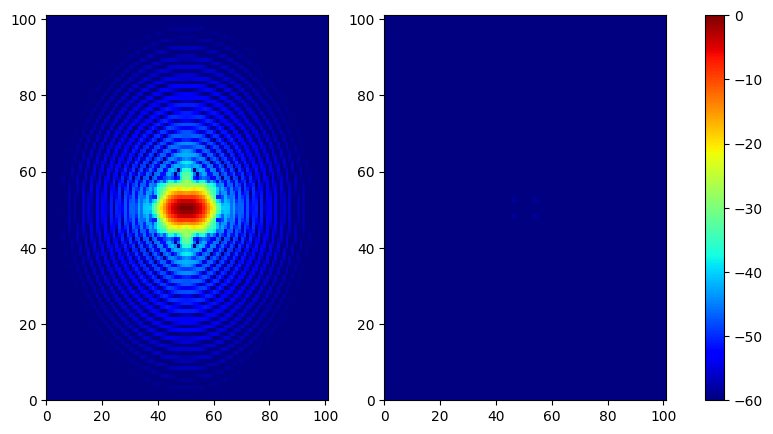

In [12]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
Max = np.abs(Beammap.E.x).max()
vmin = -60
p0 = ax[0].pcolor(np.log10(np.abs(Beammap.E.x.reshape(101,-1))/Max)*20,cmap = 'jet',vmax= 0, vmin = vmin)
p1 = ax[1].pcolor(np.log10(np.abs(Beammap.E.y.reshape(101,-1))/Max)*20,cmap = 'jet',vmax= 0, vmin = vmin)
cbar = fig.colorbar(p0,ax = ax.ravel())

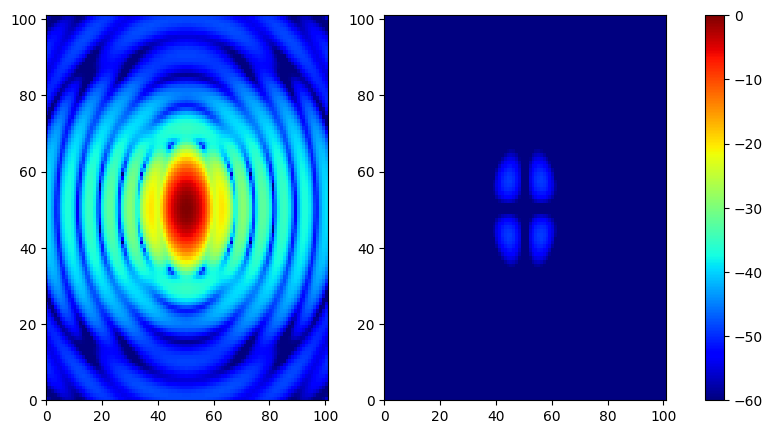

In [13]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
Max = np.abs(OutputBeam.E.x).max()
vmin = -60
p0 = ax[0].pcolor(np.log10(np.abs(OutputBeam.E.x.reshape(101,-1))/Max)*20,cmap = 'jet',vmax= 0, vmin = vmin)
p1 = ax[1].pcolor(np.log10(np.abs(OutputBeam.E.y.reshape(101,-1))/Max)*20,cmap = 'jet',vmax= 0, vmin = vmin)
cbar = fig.colorbar(p0,ax = ax.ravel())

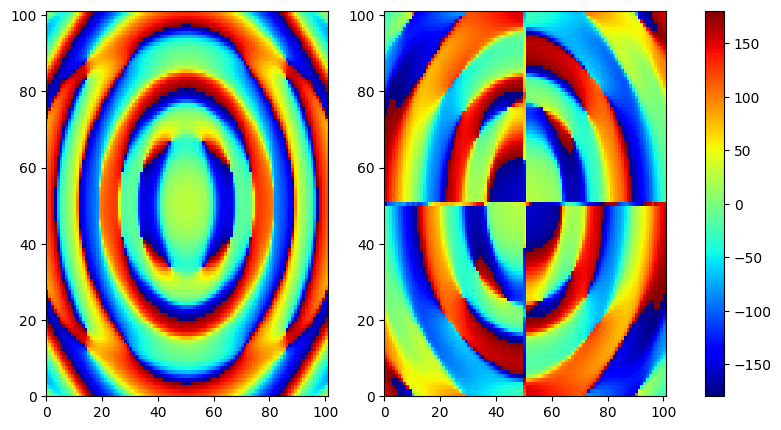

In [14]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
Max = np.abs(OutputBeam.E.x).max()
p0 = ax[0].pcolor(np.angle(OutputBeam.E.x.reshape(101,-1))*180/np.pi,cmap = 'jet',vmax= 180, vmin = -180)
p1 = ax[1].pcolor(np.angle(OutputBeam.E.y.reshape(101,-1))*180/np.pi,cmap = 'jet',vmax= 180, vmin = -180)
cbar = fig.colorbar(p0,ax = ax.ravel())